# Exploratory Data Analysis: Bird Diversity & Environmental Factors
This notebook explores the relationship between various bird species and their environmental preferences in Sri Lanka based on the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
%matplotlib inline


In [2]:
import os
data_path = '../file6.csv'
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Data file not found at {data_path}")

print("Loading data...")
df = pd.read_csv(data_path)
print(f"Original Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Sample the data to 300,000 rows if it is very large to speed up EDA, plotting and model training
if df.shape[0] > 300000:
    df = df.sample(300000, random_state=42)
    print(f"Sampled Data for EDA: {df.shape[0]} rows")

df.head()


Loading data...
Original Data loaded: 1552048 rows, 24 columns
Sampled Data for EDA: 300000 rows


,index,verbatimScientificName,stateProvince,individualCount,decimalLatitude,decimalLongitude,eventDate,avg_rad,NDVI_raw,LandCover_Class,...,Sulfate_Mass,Sea_Salt_Mass,Total_Aerosol_Extinction,temp_mean,rainfall,wind_mean,humid_mean,shortwave_radiation,lka_general_2020,NDVI
984385,1511954,Psittacula krameri,Colombo,21.0,6.889741,79.944240,2021-06-23,6.04,3934.0,13,...,9.041211e-10,6.623026e-08,0.214635,26.59,2.89,4.32,85.56,19.52,6.585009,0.3934
1451809,2228822,Acridotheres tristis,Gampaha,5.0,7.239253,80.099600,2024-09-18,0.87,7752.0,8,...,1.169898e-09,5.924096e-08,0.191869,27.17,0.83,4.54,87.08,22.95,4.518574,0.7752
830664,1275508,Microcarbo niger,Colombo,1.0,6.879259,79.930664,2023-02-03,11.83,7653.0,13,...,2.872023e-09,1.979469e-08,0.135618,25.77,11.89,3.75,87.19,10.23,10.476233,0.7653
837827,1286435,Microcarbo niger,Colombo,1.0,6.888931,79.946450,2024-06-19,6.95,5296.0,13,...,8.739435e-10,7.662718e-08,0.193012,27.20,4.57,4.95,88.26,17.41,6.585009,0.5296
1084455,1665585,Gallus lafayettii,Kalutara,7.0,6.467277,80.119835,2020-04-27,0.98,8996.0,8,...,2.050449e-09,2.450879e-08,0.190148,28.24,5.80,2.25,85.34,23.05,7.254956,0.8996


### Basic Dataset Overview

In [3]:
df.info()


<class 'pandas.DataFrame'>
Index: 300000 entries, 984385 to 343522
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   index                     300000 non-null  int64  
 1   verbatimScientificName    300000 non-null  str    
 2   stateProvince             300000 non-null  str    
 3   individualCount           300000 non-null  float64
 4   decimalLatitude           300000 non-null  float64
 5   decimalLongitude          300000 non-null  float64
 6   eventDate                 300000 non-null  str    
 7   avg_rad                   300000 non-null  float64
 8   NDVI_raw                  300000 non-null  float64
 9   LandCover_Class           300000 non-null  int64  
 10  elevation_meters          300000 non-null  int64  
 11  Carbon_Mass               300000 non-null  float64
 12  Dust_Mass                 300000 non-null  float64
 13  SO2_Mass                  300000 non-null  float64
 14 

In [4]:
print("\nMissing Values in the sampled subset:")
print(df.isnull().sum())



Missing Values in the sampled subset:
index                       0
verbatimScientificName      0
stateProvince               0
individualCount             0
decimalLatitude             0
decimalLongitude            0
eventDate                   0
avg_rad                     0
NDVI_raw                    0
LandCover_Class             0
elevation_meters            0
Carbon_Mass                 0
Dust_Mass                   0
SO2_Mass                    0
Sulfate_Mass                0
Sea_Salt_Mass               0
Total_Aerosol_Extinction    0
temp_mean                   0
rainfall                    0
wind_mean                   0
humid_mean                  0
shortwave_radiation         0
lka_general_2020            0
NDVI                        0
dtype: int64


### Top Frequently Observed Bird Species

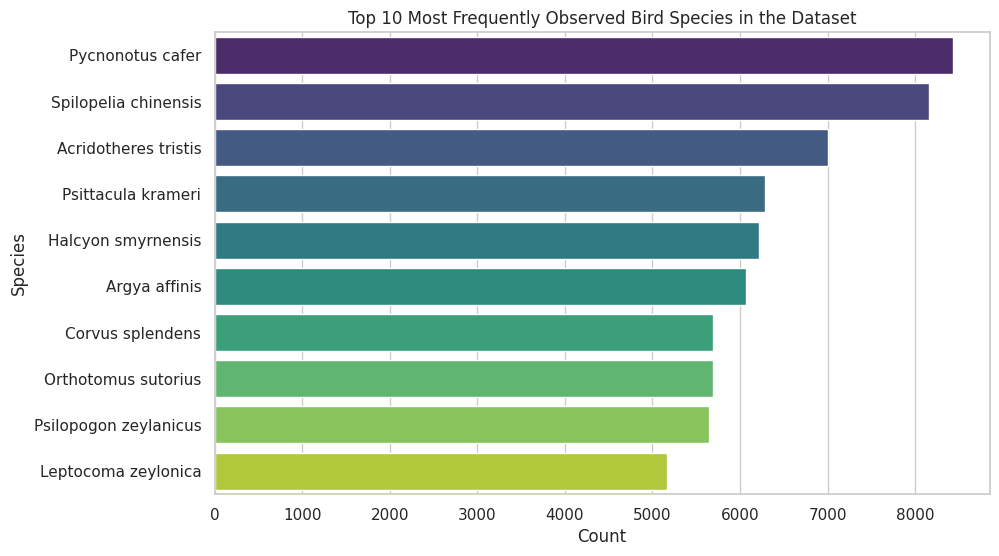

In [5]:
# Identify the top 10 most common bird species
top_species = df['verbatimScientificName'].value_counts().head(10).index.tolist()
plt.figure(figsize=(10,6))
sns.countplot(data=df[df['verbatimScientificName'].isin(top_species)], y='verbatimScientificName', order=top_species, palette='viridis')
plt.title('Top 10 Most Frequently Observed Bird Species in the Dataset')
plt.xlabel('Count')
plt.ylabel('Species')
plt.show()


### Relationship Between Bird Species and Geography (Elevation)

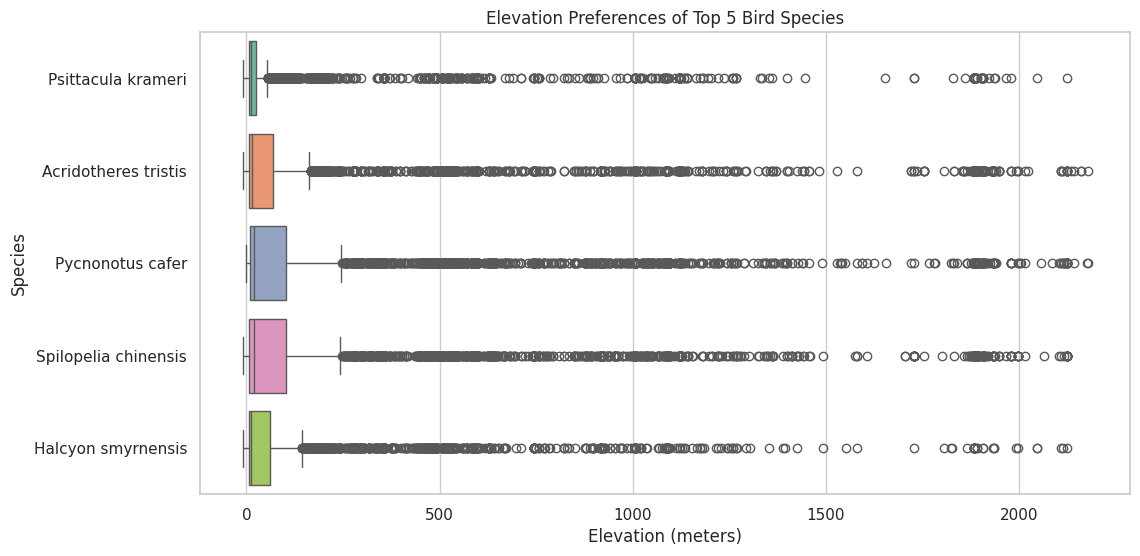

In [6]:
# Compare elevation distribution for the top 5 species
top_5 = top_species[:5]
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df['verbatimScientificName'].isin(top_5)], x='elevation_meters', y='verbatimScientificName', palette='Set2')
plt.title('Elevation Preferences of Top 5 Bird Species')
plt.xlabel('Elevation (meters)')
plt.ylabel('Species')
plt.show()


### Impact of Weather Features: Temperature and Rainfall
Understanding what climatological boundaries these birds prefer.

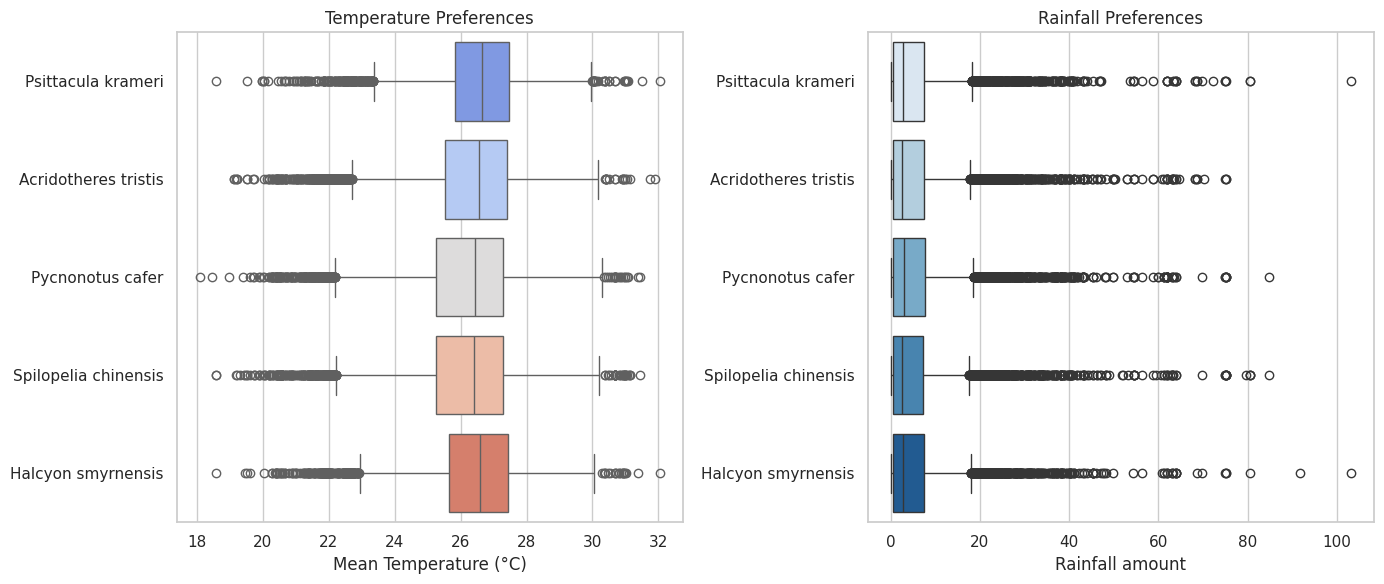

In [7]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df[df['verbatimScientificName'].isin(top_5)], x='temp_mean', y='verbatimScientificName', palette='coolwarm')
plt.title('Temperature Preferences')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('')

plt.subplot(1, 2, 2)
sns.boxplot(data=df[df['verbatimScientificName'].isin(top_5)], x='rainfall', y='verbatimScientificName', palette='Blues')
plt.title('Rainfall Preferences')
plt.xlabel('Rainfall amount')
plt.ylabel('')

plt.tight_layout()
plt.show()


### Vegetation (NDVI) and Human Light Pollution (avg_rad)
Differentiating forest-dependent birds from human-adapted (urban) birds using NDVI and Night Time Light.

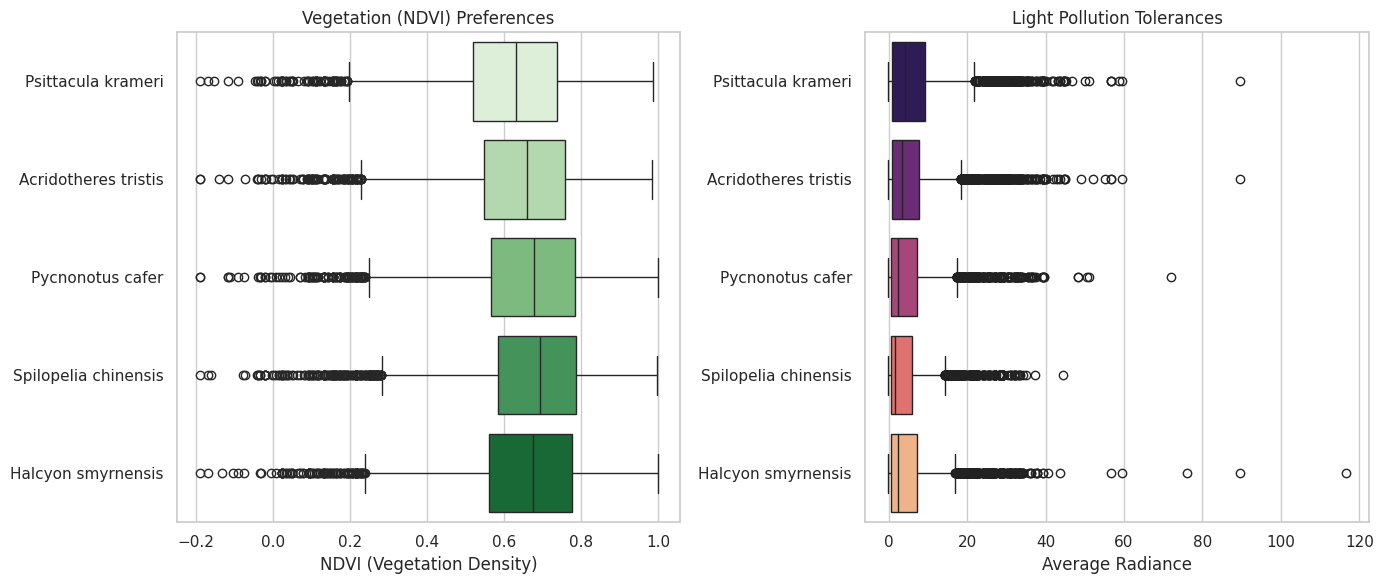

In [8]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df[df['verbatimScientificName'].isin(top_5)], x='NDVI', y='verbatimScientificName', palette='Greens')
plt.title('Vegetation (NDVI) Preferences')
plt.xlabel('NDVI (Vegetation Density)')
plt.ylabel('')

plt.subplot(1, 2, 2)
sns.boxplot(data=df[df['verbatimScientificName'].isin(top_5)], x='avg_rad', y='verbatimScientificName', palette='magma')
plt.title('Light Pollution Tolerances')
plt.xlabel('Average Radiance')
plt.ylabel('')

plt.tight_layout()
plt.show()


### Land Cover Distrubution for Species

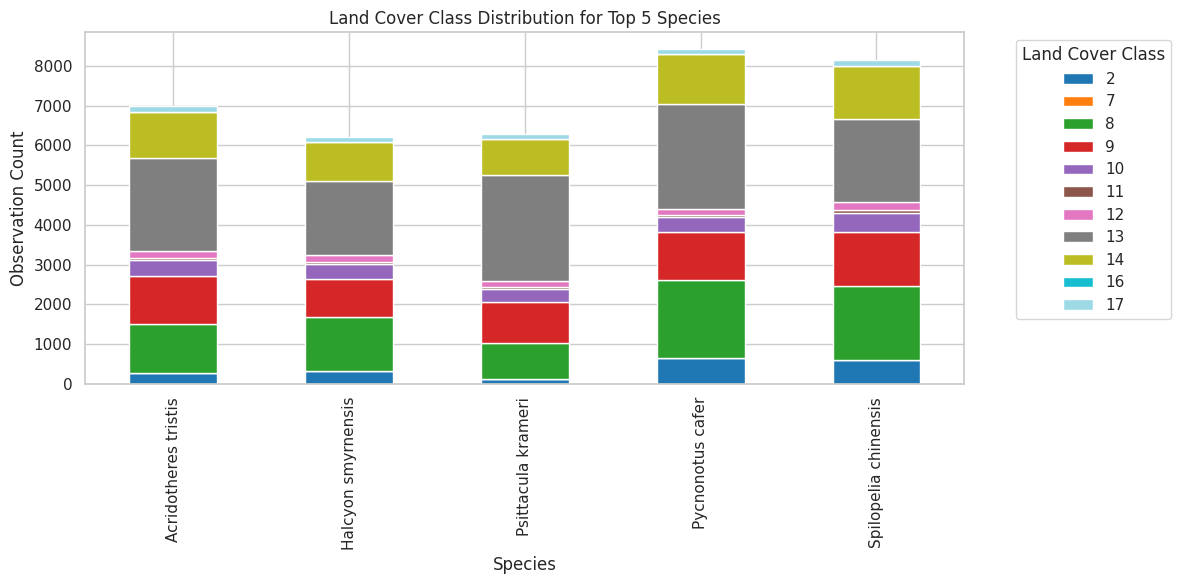

In [9]:
lc_counts = df[df['verbatimScientificName'].isin(top_5)].groupby(['verbatimScientificName', 'LandCover_Class']).size().unstack().fillna(0)
lc_counts.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title('Land Cover Class Distribution for Top 5 Species')
plt.xlabel('Species')
plt.ylabel('Observation Count')
plt.legend(title='Land Cover Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Environmental Features Correlation Heatmap

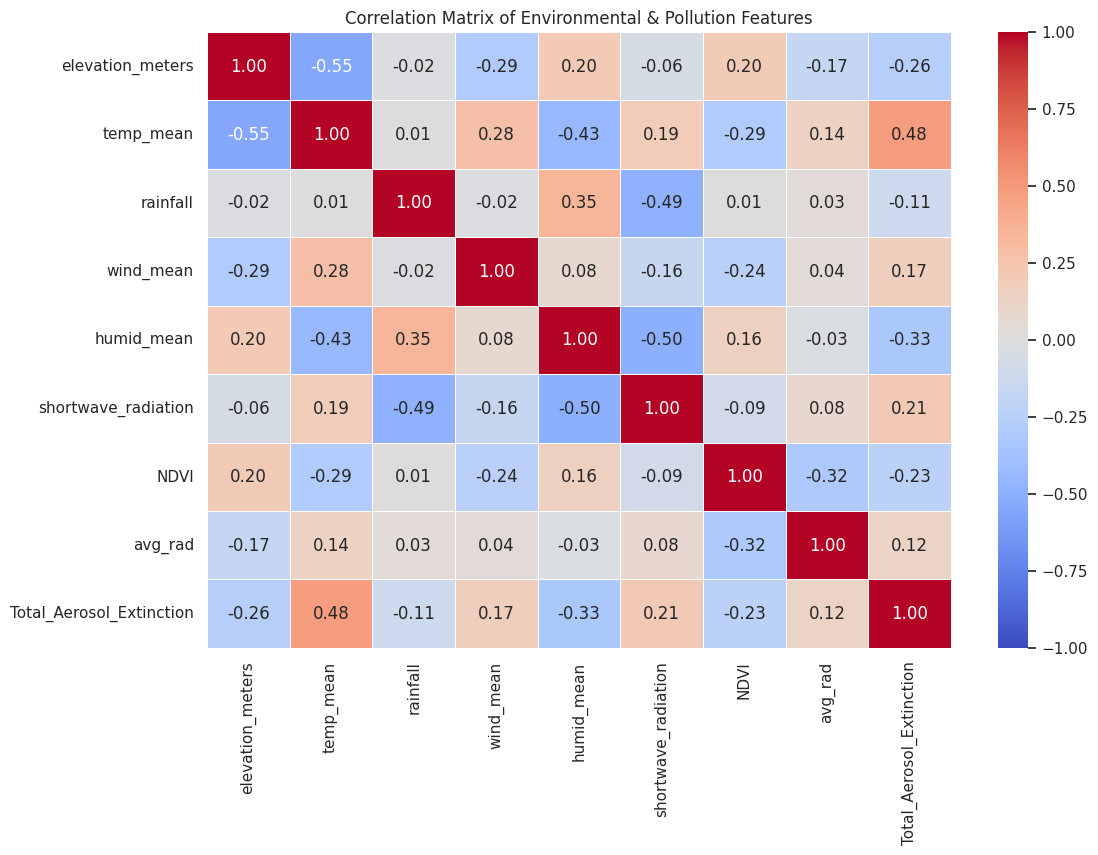

In [10]:
# Define the continuous features of interest related to the environment
features = ['elevation_meters', 'temp_mean', 'rainfall', 'wind_mean', 'humid_mean', 
            'shortwave_radiation', 'NDVI', 'avg_rad', 'Total_Aerosol_Extinction']

plt.figure(figsize=(12, 8))
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=.5)
plt.title('Correlation Matrix of Environmental & Pollution Features')
plt.show()


### Feature Importance: Why Birds Stay or Leave a Location
To understand what features primarily separate different species' locations, we train a Random Forest model to predict the species based strictly on environmental conditions.

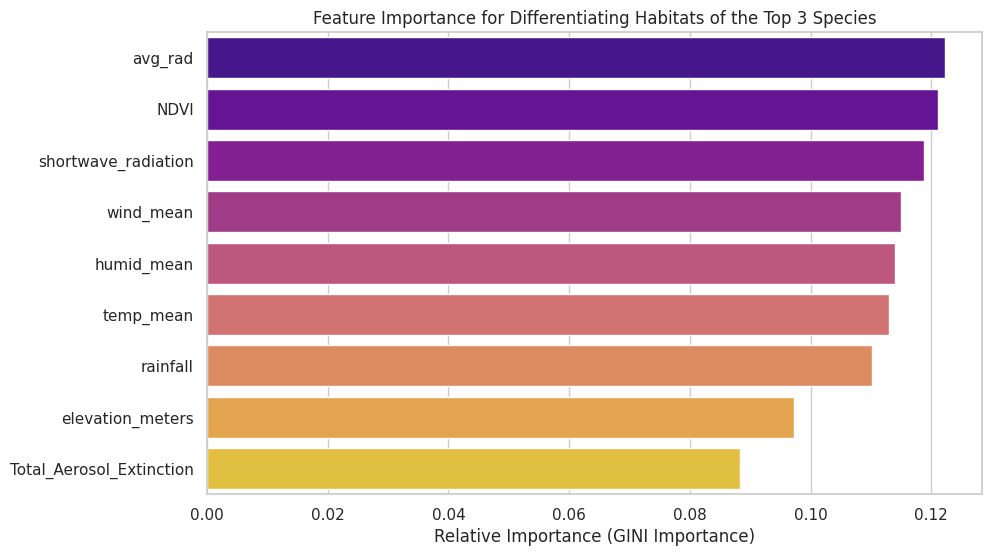

Classification Report (Differentiating Top 3 Species Habitats):

                      precision    recall  f1-score   support

Acridotheres tristis       0.30      0.26      0.28      2141
    Pycnonotus cafer       0.33      0.36      0.34      2492
Spilopelia chinensis       0.32      0.32      0.32      2444

            accuracy                           0.32      7077
           macro avg       0.32      0.32      0.32      7077
        weighted avg       0.32      0.32      0.32      7077



In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# Subset the data for the top 3 species and the defined continuous features
top_3 = top_species[:3]
df_subset = df[df['verbatimScientificName'].isin(top_3)].dropna(subset=features + ['verbatimScientificName'])

X = df_subset[features]
y = df_subset['verbatimScientificName']

# Encode the species names to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Plot Feature Importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette='plasma')
plt.title('Feature Importance for Differentiating Habitats of the Top 3 Species')
plt.xlabel('Relative Importance (GINI Importance)')
plt.show()

# Evaluation
y_pred = rf.predict(X_test)
print("Classification Report (Differentiating Top 3 Species Habitats):\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


### Principal Component Analysis (PCA)
Let's see if the environmental features cluster naturally for the top 3 species.

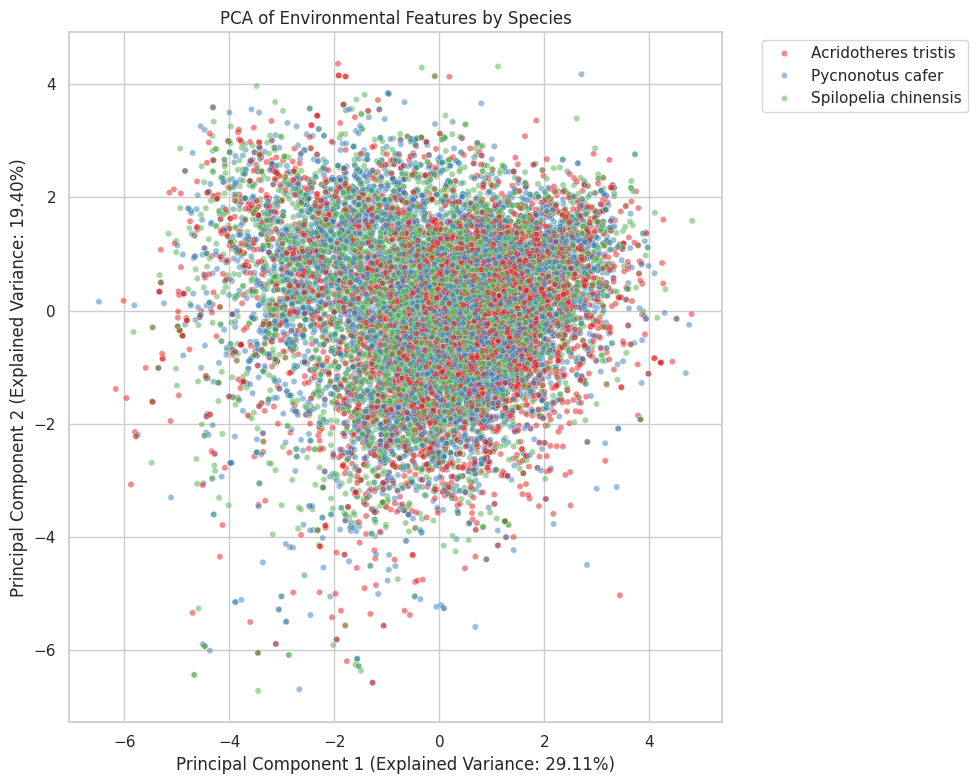

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({'PC1': X_pca[:,0], 'PC2': X_pca[:,1], 'Species': y})

# Since plotting too many points in a scatterplot can be heavy, we plot a sample if needed
df_pca_sample = df_pca.sample(min(20000, len(df_pca)), random_state=42)

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca_sample, x='PC1', y='PC2', hue='Species', palette='Set1', alpha=0.5, s=20)
plt.title('PCA of Environmental Features by Species')
plt.xlabel(f'Principal Component 1 (Explained Variance: {pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Principal Component 2 (Explained Variance: {pca.explained_variance_ratio_[1]:.2%})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Conclusion
1. **Bird Habitats**: Specific species show strong associations with elevation, temperature distributions, and regional characteristics (e.g., NDVI/Vegetation). For example, some might strictly prefer coastal, lower elevations while others inhabit the central highlands.
2. **Environmental Thresholds**: By checking the most crucial features (like `temp_mean`, `NDVI`, `elevation_meters`), we can see what affects their choice of location the most, either pushing them to stay or preventing them from establishing populations.
3. **Predictive Capability**: The Random Forest scores prove that the set of geographic/climatological features (`temp_mean`, `humid_mean`, `elevation_meters`) hold strong predictive power for predicting which species out of the top candidates is likely to exist in a particular environment.
